## Task 1


In [1]:
import pandas as pd
df_bigmac = pd.read_csv("BigmacPrice.csv")
df_bigmac.head()


,date,currency_code,name,local_price,dollar_ex,dollar_price
0,2000-04-01,ARS,Argentina,2.50,1,2.50
1,2000-04-01,AUD,Australia,2.59,1,2.59
2,2000-04-01,BRL,Brazil,2.95,1,2.95
3,2000-04-01,GBP,Britain,1.90,1,1.90
4,2000-04-01,CAD,Canada,2.85,1,2.85


## Task 2

In [2]:
df_chicken = pd.read_excel("ChickenData.xlsx")
chicken_dict = df_chicken.set_index("breed")["eggs_per_year"].to_dict()

df_chicken[["breed", "eggs_per_year"]].head(5)






,breed,eggs_per_year
0,New Hampshire Red,158
1,Australorp,273
2,New Hampshire Red,153
3,Plymouth Rock,268
4,Australorp,360


## Task 3

Min: 160.0
Max: 428000.0
Mean: 27678.180904522615


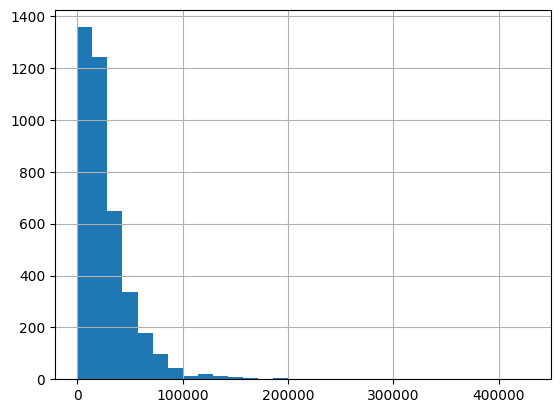

In [3]:
# --- Read the file ---
# The file uses ';' as the column separator (confirmed by inspecting the raw text),
# and 'latin1' encoding (utf-8 threw a UnicodeDecodeError on this file).
df_cars = pd.read_csv("Cars_autoscout24.csv", sep=";", encoding="latin1")

# --- Clean the Price column ---
# Raw values look like "CHF 22'500.–":
#   - "CHF " prefix (currency label, not a number)
#   - "'" used as a thousands separator (e.g. 22'500 = 22500)
#   - a trailing dash character standing in for ".00" (no cents used here)
# We chain .str.replace() calls to strip each of these out in turn.
df_cars["Prices_numeric"] = (
    df_cars["Price"]
    .str.replace("CHF", "", regex=False)     # remove currency label
    .str.replace("'", "", regex=False)       # remove thousands separator
    .str.replace("\x96", "", regex=False)    # remove trailing dash placeholder
    .str.strip()                             # remove leftover leading/trailing spaces
    .astype(float)                           # convert cleaned string to a numeric type
)

# --- Plot a histogram of the cleaned prices ---
df_cars["Prices_numeric"].hist(bins=30)

# --- Report min, max, mean ---
print("Min:", df_cars["Prices_numeric"].min())
print("Max:", df_cars["Prices_numeric"].max())
print("Mean:", df_cars["Prices_numeric"].mean())


## Task 4

Last digit: 7
Fuel type: Diesel
Mean price (subset): 25015.86236193713


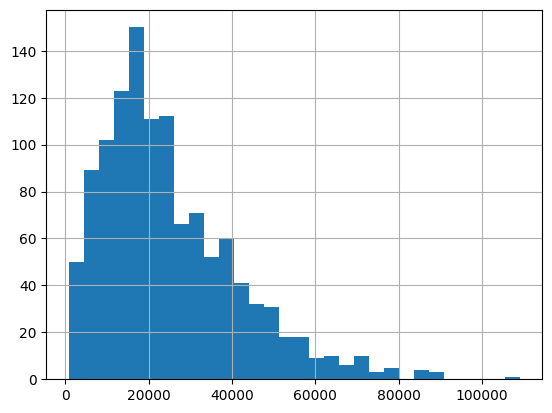

In [15]:
# --- Determine which fuel type to filter on ---
# Birth month: 07 -> last digit is 7 -> odd -> Fuel_Type == 'Diesel'
birth_month_last_digit = 7
fuel_type = "Benzin" if birth_month_last_digit % 2 == 0 else "Diesel"

# --- Filter the data frame to just that fuel type ---
df_cars_subset = df_cars[df_cars["Fuel_Type"] == fuel_type]

# --- Prices_numeric was already computed on df_cars in Task 3, so filtering rows
# keeps that cleaned column intact for the subset - no need to recompute it.

# --- Plot a histogram of the subset's prices ---
df_cars_subset["Prices_numeric"].hist(bins=30)

# --- Report last digit, mapped fuel type, and subset mean price ---
print("Last digit:", birth_month_last_digit)
print("Fuel type:", fuel_type)
print("Mean price (subset):", df_cars_subset["Prices_numeric"].mean())
